# Complaint Sense — DistilBERT Complaint Classification

**Challenge 9:** Intelligent Complaint Classification Using Localized Transformer Architectures  
**Team:** Stanley  
**Task:** Multi-class text classification of CFPB consumer complaint narratives into **11 Issue** categories  
**Primary metric:** Macro F1

Pipeline: **load → preprocess → fine-tune DistilBERT → evaluate**

### Setup
```bash
pip install -r requirements.txt
# Optional: build working CSV from full CFPB dump
python prepare_data.py --input data/complaints.csv --per-class 30
# Or download the full dump first (large):
python prepare_data.py --download --per-class 30
```

Place `data/complaint_sense_working.csv` (preferred) or a raw CFPB `data/complaints.csv` before training.

## 1. Install / imports

In [1]:
# Uncomment if packages are not yet installed in this kernel
%pip install -q pandas numpy scikit-learn matplotlib seaborn torch transformers datasets accelerate evaluate tqdm requests

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [1]:
import json
import os
import random
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2. Configuration

In [2]:
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models" / "distilbert-complaint-sense"
OUTPUT_DIR = ROOT / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WORKING_CSV = DATA_DIR / "complaint_sense_working.csv"
AUGMENTED_CSV = DATA_DIR / "complaint_sense_augmented.csv"
NIGERIAN_TEST_CSV = DATA_DIR / "nigerian_test_complaints.csv"
RAW_CSV = DATA_DIR / "train_complaints.csv"

# Column names in your dataset
NARRATIVE_COL = "text"
LABEL_COL = "Category"
ID_COL = "ComplaintId"

# Complaint categories in your dataset
TARGET_ISSUES = [
    "billing",
    "account_access",
    "delivery_shipping",
    "refund_return",
    "fraud_unauthorized",
    "product_defect",
    "warranty_repair",
    "subscription_cancel",
    "general_inquiry",
    "customer_service",
]

# Nigerian localization: augment TRAIN split only (after split, before tokenize)
USE_NIGERIAN_AUGMENTATION = True

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
PER_CLASS_CAP = 30
TEST_SIZE = 0.2
VAL_SIZE = 0.1  # fraction of the *train* split used for validation

# Training hyperparameters (CPU-friendly defaults; raise if you have a GPU)
NUM_EPOCHS = 4
TRAIN_BATCH_SIZE = 8 if DEVICE == "cuda" else 4
EVAL_BATCH_SIZE = 16 if DEVICE == "cuda" else 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 0.1

print("Paths ready:")
print("  working CSV:", WORKING_CSV)
print("  augmented:  ", AUGMENTED_CSV)
print("  raw CSV:    ", RAW_CSV)
print("  model dir:  ", MODEL_DIR)
print("  outputs:    ", OUTPUT_DIR)
print(f"\nDataset config:")
print(f"  text column: {NARRATIVE_COL}")
print(f"  label column: {LABEL_COL}")
print(f"  categories: {len(TARGET_ISSUES)}")
print(f"  Nigerian augmentation: {USE_NIGERIAN_AUGMENTATION}")

Paths ready:
  working CSV: C:\Users\HP\Desktop\Tri-ai\data\complaint_sense_working.csv
  augmented:   C:\Users\HP\Desktop\Tri-ai\data\complaint_sense_augmented.csv
  raw CSV:     C:\Users\HP\Desktop\Tri-ai\data\train_complaints.csv
  model dir:   C:\Users\HP\Desktop\Tri-ai\models\distilbert-complaint-sense
  outputs:     C:\Users\HP\Desktop\Tri-ai\outputs

Dataset config:
  text column: text
  label column: Category
  categories: 10
  Nigerian augmentation: True


## 3. Load data

Priority:
1. `data/complaint_sense_working.csv` (already prepared balanced subset)
2. Else build from `data/complaints.csv` (raw CFPB export) using the same rules as `prepare_data.py`

In [3]:
def clean_narrative(text: str) -> str:
    """Light cleanup that preserves informal language / typos."""
    if not isinstance(text, str):
        return ""

    text = text.strip()

    # Normalize whitespace while preserving punctuation/slang
    text = re.sub(r"\s+", " ", text)

    return text


def build_balanced_from_raw(
    raw_path: Path,
    per_class: int = PER_CLASS_CAP
) -> pd.DataFrame:

    print(f"Building working set from {raw_path} ...")

    df = pd.read_csv(raw_path, low_memory=False)

    # ---------------------------------------------------------
    # Show dataset information
    # ---------------------------------------------------------

    print(f"\nAvailable columns in {raw_path}:")
    print(df.columns.tolist())

    print("\nCategory distribution:")
    print(df[LABEL_COL].value_counts())

    # ---------------------------------------------------------
    # Verify required columns
    # ---------------------------------------------------------

    required_columns = [
        "ComplaintId",
        NARRATIVE_COL,
        LABEL_COL,
        "FamilyId",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns: {missing_columns}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    # ---------------------------------------------------------
    # Clean text
    # ---------------------------------------------------------

    df[NARRATIVE_COL] = (
        df[NARRATIVE_COL]
        .fillna("")
        .astype(str)
        .map(clean_narrative)
    )

    # Remove very short texts
    df = df[df[NARRATIVE_COL].str.len() > 20].copy()

    # Remove empty values
    df = df[
        ~df[NARRATIVE_COL].isin(["", "nan", "None"])
    ].copy()

    # ---------------------------------------------------------
    # Keep only target categories
    # ---------------------------------------------------------

    df = df[
        df[LABEL_COL].isin(TARGET_ISSUES)
    ].copy()

    print(
        f"\nAfter category + narrative filter: "
        f"{len(df):,}"
    )

    # ---------------------------------------------------------
    # Remove duplicate narratives
    # ---------------------------------------------------------

    before = len(df)

    df = df.drop_duplicates(
        subset=[NARRATIVE_COL],
        keep="first"
    )

    print(
        f"Removed {before - len(df):,} "
        f"duplicate narratives "
        f"-> {len(df):,} unique"
    )

    # ---------------------------------------------------------
    # Balance categories
    # ---------------------------------------------------------

    parts = []

    print("\nSamples per category:")

    for category in TARGET_ISSUES:

        subset = df[
            df[LABEL_COL] == category
        ]

        n = min(
            per_class,
            len(subset)
        )

        if n == 0:
            print(
                f"WARNING: no samples for "
                f"'{category}'"
            )
            continue

        sampled = subset.sample(
            n=n,
            random_state=SEED
        )

        parts.append(sampled)

        print(
            f"  {category:<25} -> {n}"
        )

    # ---------------------------------------------------------
    # Make sure we actually have data
    # ---------------------------------------------------------

    if not parts:
        raise ValueError(
            "No samples matched TARGET_ISSUES.\n\n"
            f"Available categories:\n"
            f"{df[LABEL_COL].unique().tolist()}\n\n"
            f"Target categories:\n"
            f"{TARGET_ISSUES}"
        )

    # ---------------------------------------------------------
    # Combine categories
    # ---------------------------------------------------------

    balanced = pd.concat(
        parts,
        ignore_index=True
    )

    # Shuffle
    balanced = balanced.sample(
        frac=1.0,
        random_state=SEED
    ).reset_index(drop=True)

    # ---------------------------------------------------------
    # Keep only columns we actually have
    # ---------------------------------------------------------

    keep = [
        "ComplaintId",
        NARRATIVE_COL,
        LABEL_COL,
        "FamilyId",
    ]

    balanced = balanced[keep]

    # ---------------------------------------------------------
    # Save working dataset
    # ---------------------------------------------------------

    balanced.to_csv(
        WORKING_CSV,
        index=False
    )

    print(
        f"\nSaved working subset -> "
        f"{WORKING_CSV} "
        f"({len(balanced)} rows)"
    )

    print("\nFinal category distribution:")
    print(
        balanced[LABEL_COL]
        .value_counts()
    )

    return balanced


# =============================================================
# Load or build working dataset
# =============================================================

if WORKING_CSV.exists():

    df = pd.read_csv(WORKING_CSV)

    print(
        f"Loaded working CSV: "
        f"{WORKING_CSV} "
        f"({len(df)} rows)"
    )

elif RAW_CSV.exists():

    df = build_balanced_from_raw(
        RAW_CSV
    )

else:

    raise FileNotFoundError(
        "No dataset found.\n"
        f"Expected: {WORKING_CSV}\n"
        f"Or: {RAW_CSV}"
    )


# =============================================================
# Final cleaning
# =============================================================

df[NARRATIVE_COL] = (
    df[NARRATIVE_COL]
    .map(clean_narrative)
)

df = df[
    df[NARRATIVE_COL].str.len() > 20
].copy()

df = df[
    df[LABEL_COL].isin(TARGET_ISSUES)
].copy()

df = df.reset_index(drop=True)


# =============================================================
# Final inspection
# =============================================================

print("\nShape:", df.shape)

print("\nColumns:")
print(list(df.columns))

print("\nCategory distribution:")
print(df[LABEL_COL].value_counts())

print("\nSample:")
display(df.head(3))

Loaded working CSV: C:\Users\HP\Desktop\Tri-ai\data\complaint_sense_working.csv (300 rows)

Shape: (300, 4)

Columns:
['ComplaintId', 'text', 'Category', 'FamilyId']

Category distribution:
Category
warranty_repair        30
general_inquiry        30
product_defect         30
billing                30
subscription_cancel    30
refund_return          30
account_access         30
customer_service       30
fraud_unauthorized     30
delivery_shipping      30
Name: count, dtype: int64

Sample:


,ComplaintId,text,Category,FamilyId
0,236,Hi support — Repair appointment canceled by ve...,warranty_repair,template:warranty_repair:7
1,230,Do you offer student pricing on annual softwar...,general_inquiry,template:general_inquiry:1
2,267,"Hello, The laptop screen flickers after only t...",product_defect,template:product_defect:0


## 4. Exploratory checks (class balance & leakage)

Exact duplicate narratives remaining: 0

Class distribution:


,count
Category,
billing,30
account_access,30
delivery_shipping,30
refund_return,30
fraud_unauthorized,30
product_defect,30
warranty_repair,30
subscription_cancel,30
general_inquiry,30


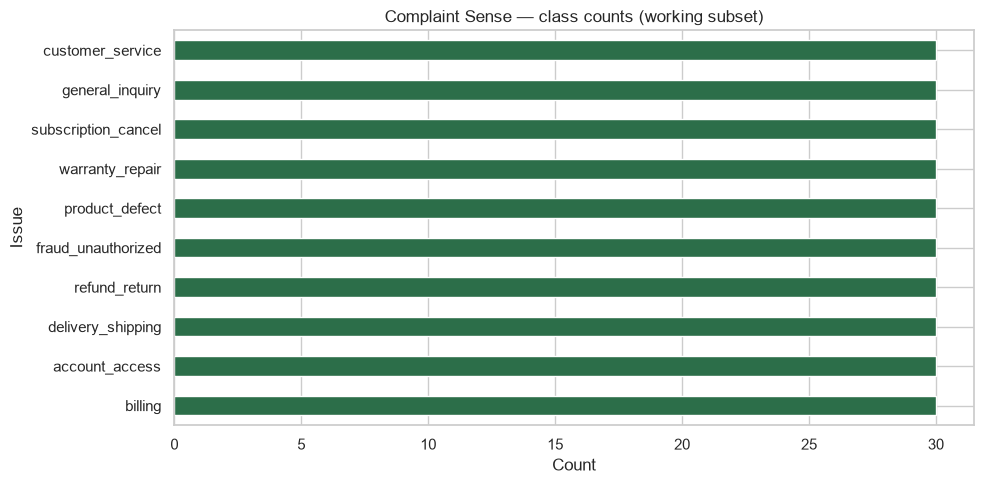


Narrative word-length stats:


count    300.0
mean      13.4
std        2.4
min        8.0
25%       12.0
50%       14.0
75%       15.0
max       20.0
Name: narrative_len, dtype: float64

In [21]:
dup_n = df.duplicated(subset=[NARRATIVE_COL]).sum()
print(f"Exact duplicate narratives remaining: {dup_n}")
if dup_n:
    df = df.drop_duplicates(subset=[NARRATIVE_COL], keep="first").reset_index(drop=True)
    print(f"After dedupe: {len(df)} rows")

class_counts = df[LABEL_COL].value_counts().reindex(TARGET_ISSUES).fillna(0).astype(int)
print("\nClass distribution:")
display(class_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.plot(kind="barh", ax=ax, color="#2c6e49")
ax.set_xlabel("Count")
ax.set_ylabel("Issue")
ax.set_title("Complaint Sense — class counts (working subset)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

df["narrative_len"] = df[NARRATIVE_COL].str.split().str.len()
print("\nNarrative word-length stats:")
display(df["narrative_len"].describe().round(1))

## 5. Preprocess — labels, splits, tokenization

In [4]:
label2id = {label: i for i, label in enumerate(TARGET_ISSUES)}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df[LABEL_COL].map(label2id)
assert df["label_id"].notna().all(), "Found labels outside TARGET_ISSUES"

# Stratified train / test, then train / val (English originals only)
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label_id"],
)
train_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_df["label_id"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Before augmentation — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Add Nigerian Pidgin / Yoruba / Igbo / Hausa variants to TRAIN only (no test leakage)
if USE_NIGERIAN_AUGMENTATION:
    if not AUGMENTED_CSV.exists():
        raise FileNotFoundError(
            f"Missing {AUGMENTED_CSV}. Run: python augment_nigerian.py"
        )
    aug = pd.read_csv(AUGMENTED_CSV)
    train_ids = set(train_df[ID_COL].astype(str))
    aug_train = aug[
        (aug["augmentation"] != "original")
        & (aug["source_id"].astype(str).isin(train_ids))
    ].copy()
    aug_train["label_id"] = aug_train[LABEL_COL].map(label2id)
    train_aug = pd.concat([train_df, aug_train], ignore_index=True)
    train_aug = train_aug.drop_duplicates(subset=[NARRATIVE_COL], keep="first")
    print(
        f"Added {len(train_aug) - len(train_df)} Nigerian variants -> "
        f"train size {len(train_df)} -> {len(train_aug)}"
    )
    train_df = train_aug.reset_index(drop=True)

print(f"\nFinal — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain class counts:")
print(train_df[LABEL_COL].value_counts().reindex(TARGET_ISSUES).fillna(0).astype(int))

# Persist splits for reproducibility / data card updates
train_df.to_csv(OUTPUT_DIR / "train.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test.csv", index=False)

with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}, f, indent=2)

Before augmentation — Train: 216 | Val: 24 | Test: 60
Added 805 Nigerian variants -> train size 216 -> 1021

Final — Train: 1021 | Val: 24 | Test: 60

Train class counts:
Category
billing                103
account_access         103
delivery_shipping      103
refund_return          103
fraud_unauthorized     102
product_defect         103
warranty_repair        101
subscription_cancel    101
general_inquiry        106
customer_service        96
Name: count, dtype: int64


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_ds = ComplaintDataset(train_df[NARRATIVE_COL], train_df["label_id"], tokenizer)
val_ds = ComplaintDataset(val_df[NARRATIVE_COL], val_df["label_id"], tokenizer)
test_ds = ComplaintDataset(test_df[NARRATIVE_COL], test_df["label_id"], tokenizer)

sample = train_ds[0]
print({k: (tuple(v.shape) if hasattr(v, "shape") else v) for k, v in sample.items()})
print("Decoded preview:", tokenizer.decode(sample["input_ids"][:40], skip_special_tokens=True))

{'input_ids': (256,), 'token_type_ids': (256,), 'attention_mask': (256,), 'labels': ()}
Decoded preview: writing to complain : unknown party used saved card for renewal i did not authorize. please advise.


## 6. Fine-tune DistilBERT

In [6]:
TARGET_ISSUES = [
    "billing",
    "account_access",
    "delivery_shipping",
    "refund_return",
    "fraud_unauthorized",
    "product_defect",
    "warranty_repair",
    "subscription_cancel",
    "general_inquiry",
    "customer_service",
]

label2id = {
    label: idx
    for idx, label in enumerate(TARGET_ISSUES)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

print(label2id)
print(id2label)

{'billing': 0, 'account_access': 1, 'delivery_shipping': 2, 'refund_return': 3, 'fraud_unauthorized': 4, 'product_defect': 5, 'warranty_repair': 6, 'subscription_cancel': 7, 'general_inquiry': 8, 'customer_service': 9}
{0: 'billing', 1: 'account_access', 2: 'delivery_shipping', 3: 'refund_return', 4: 'fraud_unauthorized', 5: 'product_defect', 6: 'warranty_repair', 7: 'subscription_cancel', 8: 'general_inquiry', 9: 'customer_service'}


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(TARGET_ISSUES),
    id2label=id2label,
    label2id=label2id,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    weighted_f1 = f1_score(labels, preds, average="weighted", zero_division=0)
    return {
        "accuracy": acc,
        "macro_f1": f1,
        "weighted_f1": weighted_f1,
        "macro_precision": precision,
        "macro_recall": recall,
    }


training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting fine-tune...")
train_result = trainer.train()
print("Training done.")
print(train_result.metrics)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 525.74it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting fine-tune...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.389521,0.285071,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.092496,0.018391,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.017179,0.009280,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]


Training done.
{'train_runtime': 5609.8849, 'train_samples_per_second': 0.728, 'train_steps_per_second': 0.183, 'total_flos': 202902764774400.0, 'train_loss': 0.4997319206595421, 'epoch': 3.0}


In [8]:
# Save best model + tokenizer
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print(f"Saved model to {MODEL_DIR}")

val_metrics = trainer.evaluate()
print("Validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.10s/it]


Saved model to C:\Users\HP\Desktop\Tri-ai\models\distilbert-complaint-sense


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0.017179,0.285071,3,1.000000,1.000000,1.000000,1.000000,1.000000


Validation metrics:
  eval_loss: 0.2851
  eval_accuracy: 1.0000
  eval_macro_f1: 1.0000
  eval_weighted_f1: 1.0000
  eval_macro_precision: 1.0000
  eval_macro_recall: 1.0000


## 7. Evaluate on held-out test set (Macro F1 + per-class metrics)

In [9]:
pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
acc = accuracy_score(y_true, y_pred)

print("=== Held-out test results ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {macro_f1:.4f}   <-- primary metric")
print(f"Weighted F1  : {weighted_f1:.4f}")
print()

# Short labels for readable reports / plots
short_names = [lbl if len(lbl) <= 42 else lbl[:39] + "..." for lbl in TARGET_ISSUES]

report = classification_report(
    y_true,
    y_pred,
    target_names=short_names,
    digits=3,
    zero_division=0,
)
print(report)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_ISSUES,
    output_dict=True,
    zero_division=0,
)
per_class = (
    pd.DataFrame(report_dict)
    .T.loc[TARGET_ISSUES, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
display(per_class.round(3))

summary = {
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "n_test": int(len(y_true)),
    "model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "epochs": NUM_EPOCHS,
}
with open(OUTPUT_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
per_class.to_csv(OUTPUT_DIR / "per_class_metrics.csv")
print(f"\nWrote {OUTPUT_DIR / 'test_metrics.json'}")
print(f"Wrote {OUTPUT_DIR / 'per_class_metrics.csv'}")

=== Held-out test results ===
Accuracy     : 0.9167
Macro F1     : 0.9124   <-- primary metric
Weighted F1  : 0.9124

                     precision    recall  f1-score   support

            billing      1.000     1.000     1.000         6
     account_access      1.000     0.667     0.800         6
  delivery_shipping      0.667     1.000     0.800         6
      refund_return      1.000     0.500     0.667         6
 fraud_unauthorized      0.750     1.000     0.857         6
     product_defect      1.000     1.000     1.000         6
    warranty_repair      1.000     1.000     1.000         6
subscription_cancel      1.000     1.000     1.000         6
    general_inquiry      1.000     1.000     1.000         6
   customer_service      1.000     1.000     1.000         6

           accuracy                          0.917        60
          macro avg      0.942     0.917     0.912        60
       weighted avg      0.942     0.917     0.912        60



,precision,recall,f1,support
billing,1.000,1.000,1.000,6.0
account_access,1.000,0.667,0.800,6.0
delivery_shipping,0.667,1.000,0.800,6.0
refund_return,1.000,0.500,0.667,6.0
fraud_unauthorized,0.750,1.000,0.857,6.0
product_defect,1.000,1.000,1.000,6.0
warranty_repair,1.000,1.000,1.000,6.0
subscription_cancel,1.000,1.000,1.000,6.0
general_inquiry,1.000,1.000,1.000,6.0
customer_service,1.000,1.000,1.000,6.0



Wrote C:\Users\HP\Desktop\Tri-ai\outputs\test_metrics.json
Wrote C:\Users\HP\Desktop\Tri-ai\outputs\per_class_metrics.csv


## 7b. Nigerian-language test set (Pidgin / Yoruba / Igbo / Hausa)

Held-out complaints written in Nigerian English, Pidgin, and code-mixed forms. This is separate from the English test split and measures whether the model handles localized language.

In [10]:
if NIGERIAN_TEST_CSV.exists():
    ng_test = pd.read_csv(NIGERIAN_TEST_CSV)
    ng_test["label_id"] = ng_test[LABEL_COL].map(label2id)
    ng_ds = ComplaintDataset(ng_test[NARRATIVE_COL], ng_test["label_id"], tokenizer)
    ng_pred = trainer.predict(ng_ds)
    ng_true = ng_pred.label_ids
    ng_pred_ids = np.argmax(ng_pred.predictions, axis=-1)

    ng_macro_f1 = f1_score(ng_true, ng_pred_ids, average="macro", zero_division=0)
    ng_acc = accuracy_score(ng_true, ng_pred_ids)

    print("=== Nigerian-language test set ===")
    print(f"Accuracy : {ng_acc:.4f}")
    print(f"Macro F1 : {ng_macro_f1:.4f}")

    for text, true_id, pred_id in zip(
        ng_test[NARRATIVE_COL], ng_true, ng_pred_ids
    ):
        mark = "OK" if true_id == pred_id else "MISS"
        print(f"\n[{mark}] true={id2label[true_id]} | pred={id2label[pred_id]}")
        print(f"  {text}")

    with open(OUTPUT_DIR / "nigerian_test_metrics.json", "w", encoding="utf-8") as f:
        json.dump(
            {"accuracy": float(ng_acc), "macro_f1": float(ng_macro_f1), "n_test": len(ng_true)},
            f,
            indent=2,
        )
else:
    print(f"Skip Nigerian eval — file not found: {NIGERIAN_TEST_CSV}")

=== Nigerian-language test set ===
Accuracy : 0.8000
Macro F1 : 0.7500

[OK] true=billing | pred=billing
  Abeg why dem dey charge me every month for premium support wey I no subscribe?

[MISS] true=account_access | pred=general_inquiry
  Mo ni pe account mi ti di locked, mo ko le wọle mọ.

[OK] true=delivery_shipping | pred=delivery_shipping
  I never receive my package o, e don pass two weeks.

[OK] true=refund_return | pred=refund_return
  Biko return my money, dem give me wrong product.

[OK] true=fraud_unauthorized | pred=fraud_unauthorized
  Somebody use my card without permission, barawo dem!

[OK] true=product_defect | pred=product_defect
  The laptop don spoil after two weeks, na wahala.

[OK] true=warranty_repair | pred=warranty_repair
  Dem cancel repair appointment twice, I don tire.

[OK] true=subscription_cancel | pred=subscription_cancel
  I cancel subscription but dem still dey charge me kudi.

[OK] true=general_inquiry | pred=general_inquiry
  Don Allah, una get studen

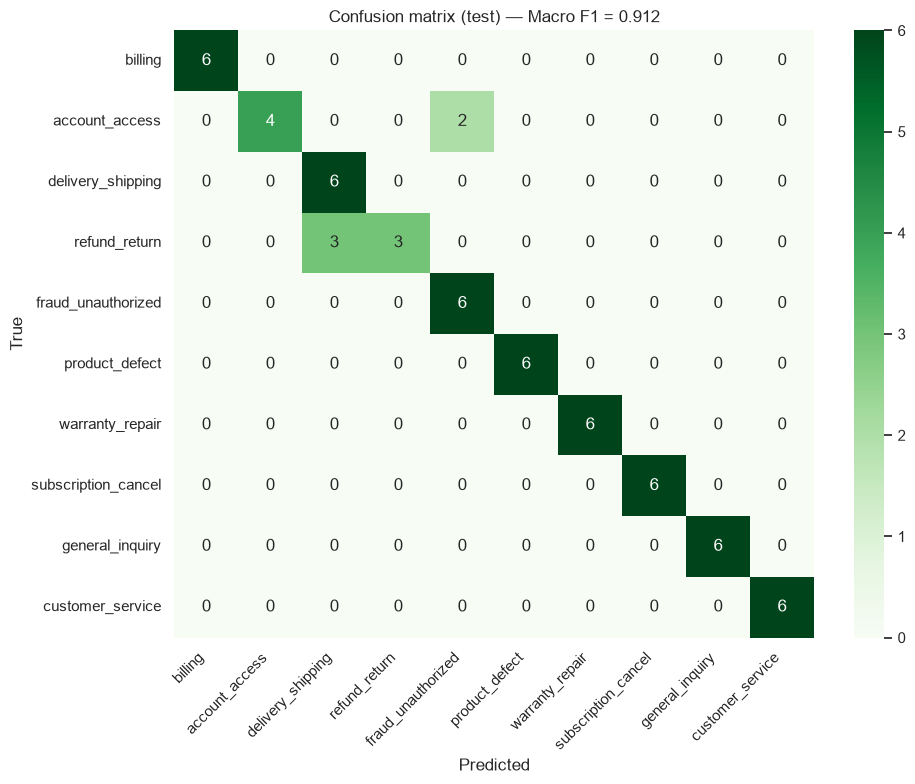

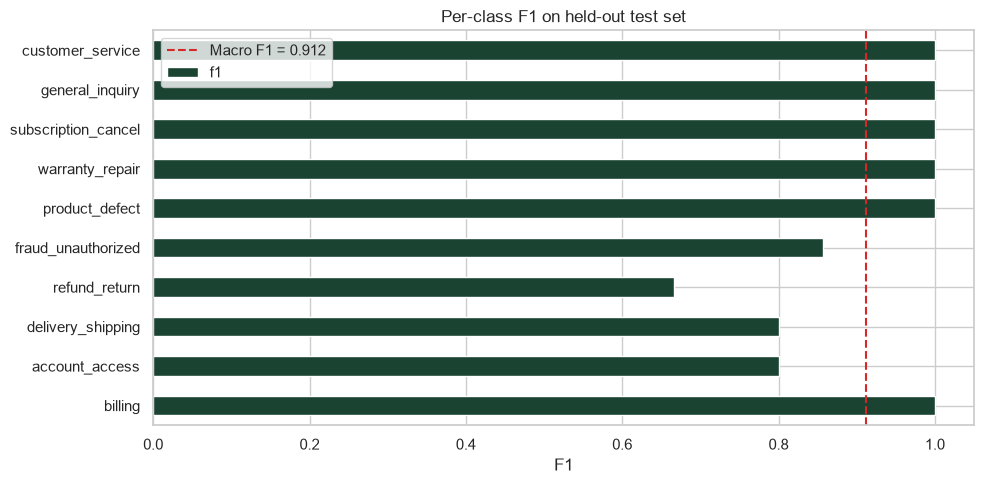

In [11]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(TARGET_ISSUES))))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=short_names,
    yticklabels=short_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test) — Macro F1 = {macro_f1:.3f}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
per_class["f1"].plot(kind="barh", ax=ax, color="#1b4332")
ax.axvline(macro_f1, color="#d62828", linestyle="--", label=f"Macro F1 = {macro_f1:.3f}")
ax.set_xlabel("F1")
ax.set_title("Per-class F1 on held-out test set")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Inference helper (single complaint)

In [12]:
def predict_complaint(text: str, model=model, tokenizer=tokenizer, top_k: int = 3):
    model.eval()
    enc = tokenizer(
        clean_narrative(text),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits.squeeze(0)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    order = np.argsort(probs)[::-1][:top_k]
    return [(id2label[i], float(probs[i])) for i in order]


demo = (
    "I keep seeing accounts on my credit report that do not belong to me. "
    "I disputed the information with the credit bureau but the same wrong "
    "balances and late payments are still showing."
)
print("Demo narrative:\n", demo, "\n")
for label, score in predict_complaint(demo):
    print(f"  {score:.3f}  {label}")

Demo narrative:
 I keep seeing accounts on my credit report that do not belong to me. I disputed the information with the credit bureau but the same wrong balances and late payments are still showing. 

  0.597  billing
  0.075  customer_service
  0.073  fraud_unauthorized


## 9. Notes for the data card / challenge write-up

| Item | Value |
|------|--------|
| Source | CFPB Consumer Complaint Database (CC0 1.0) |
| Task | Multi-class Issue classification (11 labels) |
| Model | `distilbert-base-uncased` fine-tuned |
| Primary metric | Macro F1 (equal weight per class) |
| Leakage control | Exact-duplicate narratives removed before split |
| Balancing | Cap ~30 examples/class for modelling subset |
| Values | Fairness (macro F1), transparency (per-class report), privacy (no PII reintroduction), inclusivity (light cleaning only) |

**Limitations:** English / U.S. financial complaints only; small working subset (~323) — treat metrics as a baseline, not production-ready. Ambiguous or high-risk complaints should still route to human review.

Update the data card **Baseline score** field with the Macro F1 printed in section 7 after you run the notebook.